In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel('data_test.xlsx')

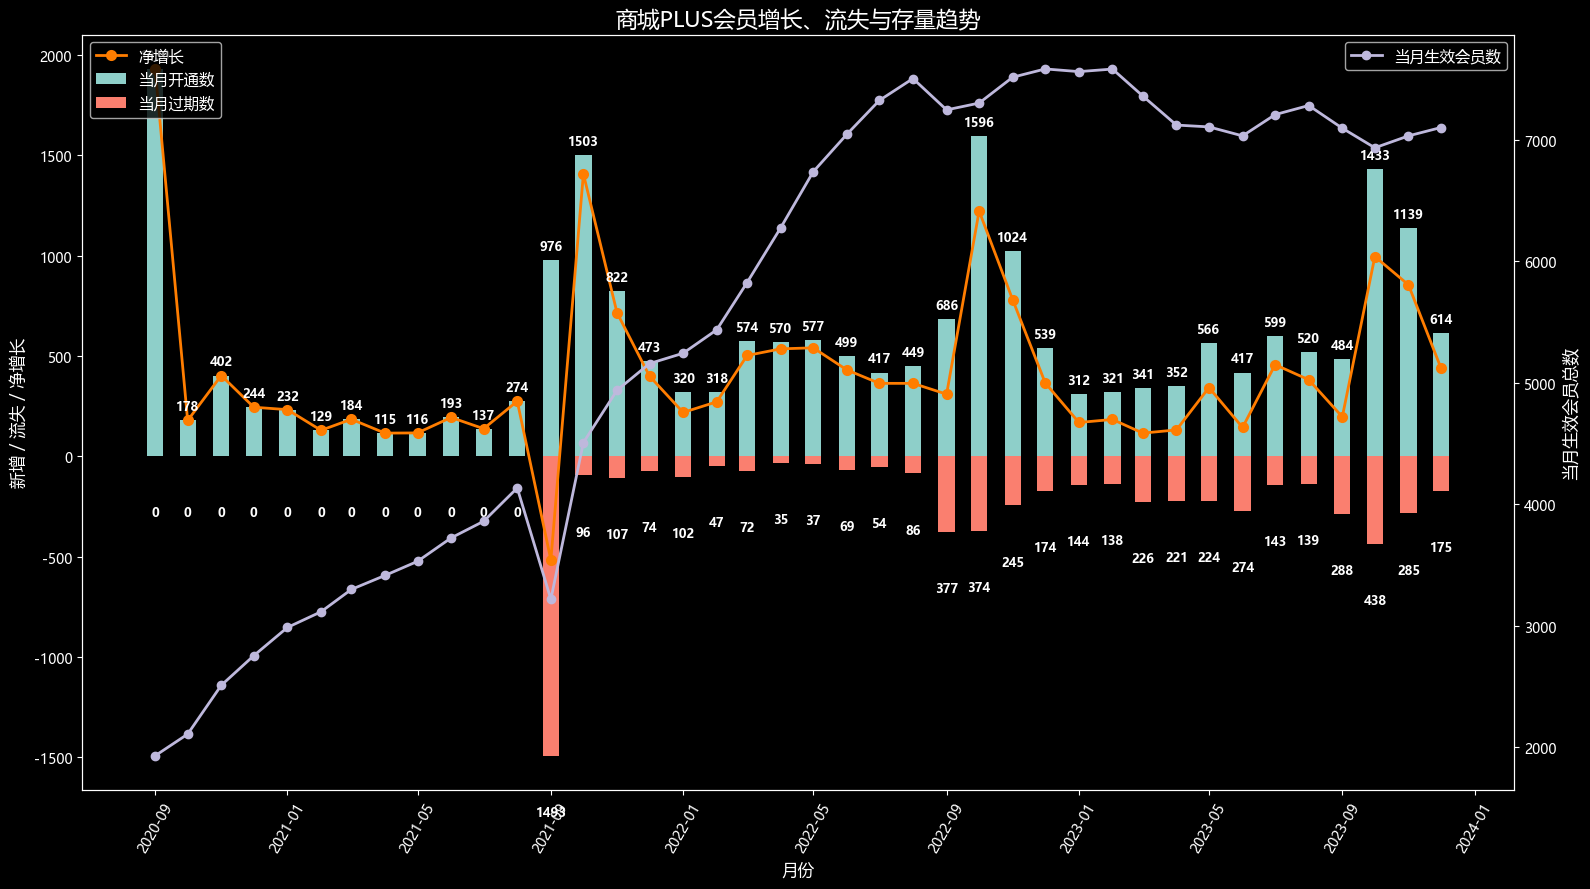

In [46]:
# -------------------------- 1. 基础字体配置 --------------------------
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']  # 商务字体
plt.rcParams['axes.unicode_minus'] = False                      # 负号正常显示
plt.rcParams['figure.dpi'] = 100                                # 高清分辨率
plt.rcParams['savefig.dpi'] = 300                               # 保存超高清

df['net_growth'] = df['new_users'] - df['expired_users']

fig, ax1 = plt.subplots(figsize=(16, 9))

# fig.patch.set_facecolor('#FCFCFC')   # 整张
# ax1.set_facecolor('#FCFCFC')          # 绘图

# 左轴：新增、流失、净增长
bars1 = ax1.bar(df['month'], df['new_users'], color='#8ECFC9', alpha=1, width=15, label='当月开通数')
bars2 = ax1.bar(df['month'], -df['expired_users'], color='#FA7F6F', alpha=1, width=15, label='当月过期数')

# ax1.bar(df['month'], df['new_users'], color='#8ECFC9', alpha=1, width=15, label='当月开通数')
# ax1.bar(df['month'], -df['expired_users'], color='#FA7F6F', alpha=1, width=15, label='当月过期数')

ax1.plot(df['month'], df['net_growth']
        , color='#FF7D00'
        , linewidth=2
        , marker='o'
        , markersize=6
        , markeredgewidth=2
        , label='净增长'
)

# -------------------- 给柱子加数值标签（核心功能） --------------------
# 给【开通数】柱子加标签
for bar in bars1:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2., height + 50,
            f'{int(height)}', ha='center', fontsize=9, fontweight='bold'
        )

# 给【过期数】柱子加标签（向下）
for bar in bars2:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2., height - 300,  # 向下偏移一点
            f'{int(-height)}', ha='center', fontsize=9, fontweight='bold'
        )

ax1.set_xlabel('月份', fontsize=12)
ax1.set_ylabel('新增 / 流失 / 净增长', fontsize=12)
# ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fontsize=11)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=11)
ax1.grid(False)  # 虚线网格，高级感

# 右轴：生效会员数
ax2 = ax1.twinx()
ax2.plot(df['month'], df['active_users'], color='#BEB8DC', linewidth=2, marker='o', label='当月生效会员数')
ax2.set_ylabel('当月生效会员总数', fontsize=12)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=11)

ax1.tick_params(axis='x', rotation=60, labelsize=10)  # 对ax1旋转

plt.title('商城PLUS会员增长、流失与存量趋势', fontsize=16)
plt.tight_layout()
plt.show()